# Customer Segmentation Analysis

## Problem Statement
Businesses want to understand different types of customers without predefined labels. We will use unsupervised learning algorithms (K-Means, Hierarchical Clustering, DBSCAN) to segment customers based on their purchasing behavior from the Mall Customers dataset.

## Tasks
1. Data Preprocessing (Scaling)
2. K-Means Clustering (Elbow & Silhouette Method)
3. Hierarchical Clustering (Dendrogram)
4. DBSCAN (Density-Based Clustering)
5. Visualization & Business Interpretation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# 3D Visualization
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')

## 1. Load and Explore Data

In [2]:
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# Quick look at the data
display(df.head())
print(df.info())

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


### Data Cleaning and Renaming
Renaming columns for easier access.

In [3]:
df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

# Check for missing values
print(df.isnull().sum())

CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64


## 2. Data Preprocessing
We need to encode the categorical 'Gender' column and Scale the numerical features for clustering algorithms.

In [4]:
# Select features for clustering
# Usually, we focus on Annual Income and Spending Score for 2D segmentation, 
# Let's create a version using Income and Score first for clear 2D visualization.
X = df[['Annual_Income', 'Spending_Score']].values

# Scaling the data (Mandatory Step)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (200, 2)


## 3. K-Means Clustering

### Determine Optimal k (The Elbow Method)

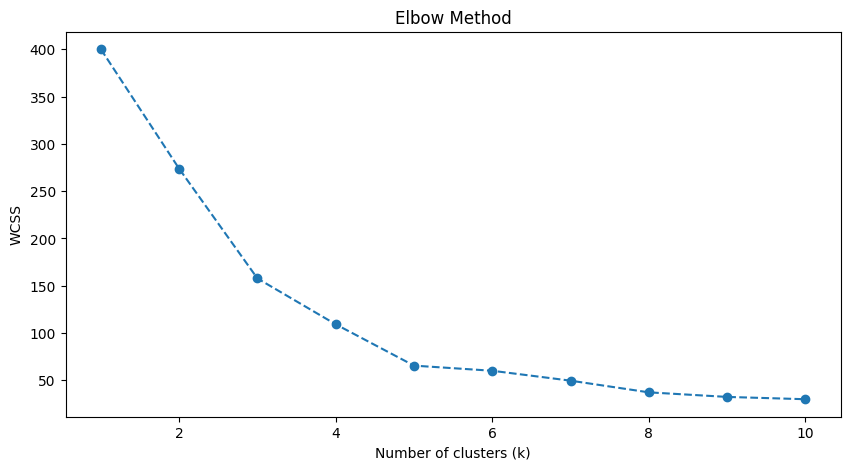

In [5]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

**Observation**: The elbow point (where the WCSS decrease slows down significantly) tends to be around **k=5** for this dataset.

### Silhouette Score Verification

In [6]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"For k={k}, Silhouette Score: {score:.3f}")

For k=2, Silhouette Score: 0.397
For k=3, Silhouette Score: 0.467
For k=4, Silhouette Score: 0.494
For k=5, Silhouette Score: 0.555
For k=6, Silhouette Score: 0.514
For k=7, Silhouette Score: 0.502
For k=8, Silhouette Score: 0.455
For k=9, Silhouette Score: 0.457
For k=10, Silhouette Score: 0.445


### Apply K-Means with Optimal k (k=5)

In [7]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster_KMeans'] = y_kmeans

### Visualize K-Means Clusters

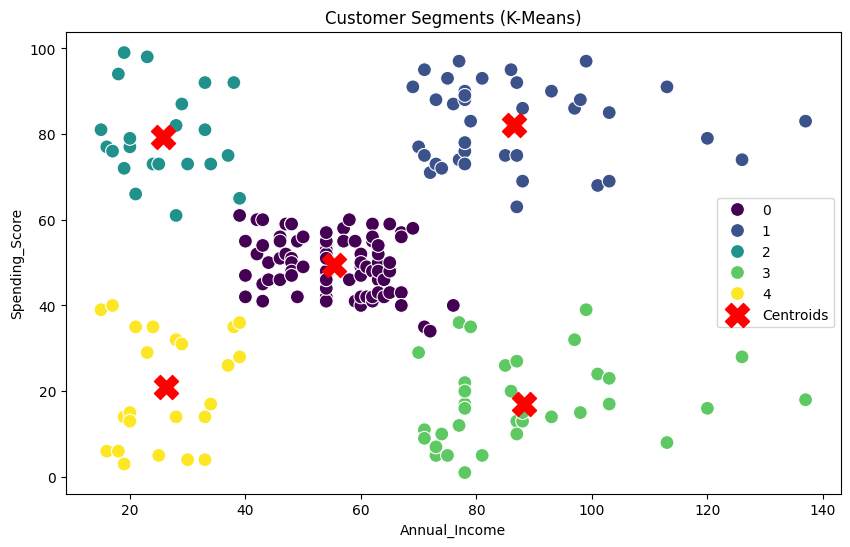

In [8]:
plt.figure(figsize=(10, 6))

centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Scatter plot for each cluster
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster_KMeans', data=df, palette='viridis', s=100)
plt.scatter(centers[:, 0], centers[:, 1], s=300, c='red', label='Centroids', marker='X')

plt.title('Customer Segments (K-Means)')
plt.legend()
plt.show()

## 4. Hierarchical Clustering

### Plot Dendrogram

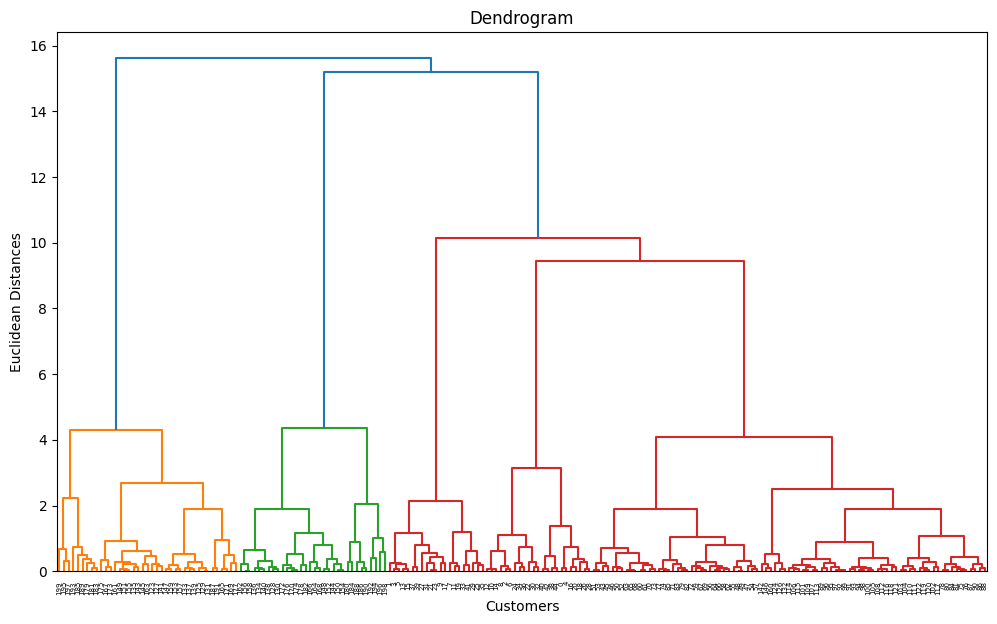

In [9]:
plt.figure(figsize=(12, 7))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

### Apply Agglomerative Clustering

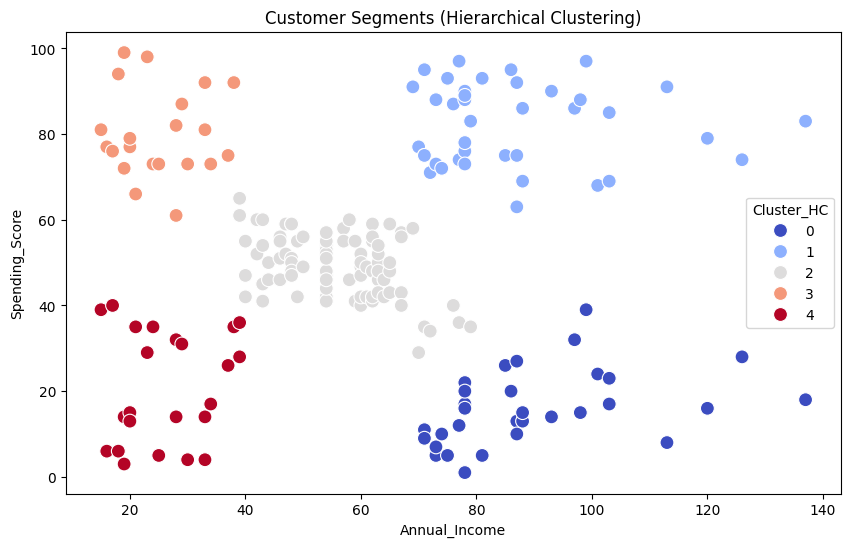

In [10]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X_scaled)

df['Cluster_HC'] = y_hc

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster_HC', data=df, palette='coolwarm', s=100)
plt.title('Customer Segments (Hierarchical Clustering)')
plt.show()

## 5. DBSCAN (Optional Bonus)

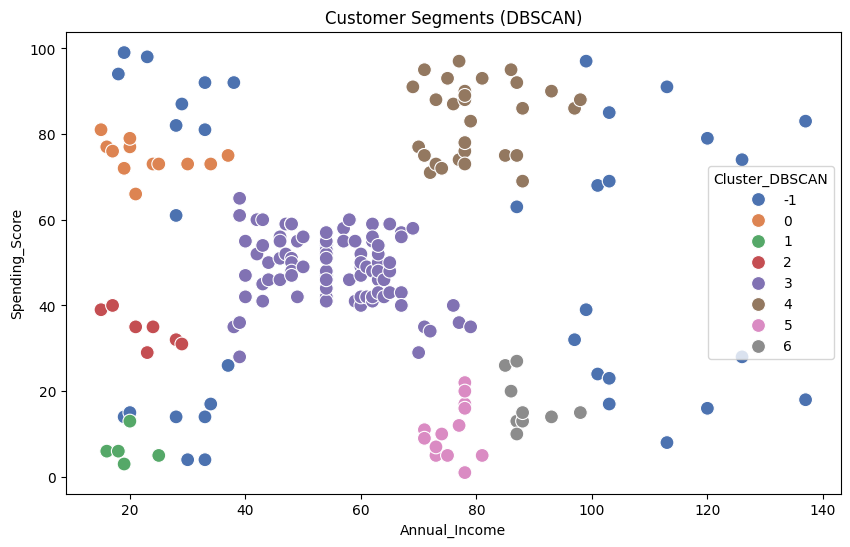

In [11]:
# DBSCAN is density based. We need to tune eps and min_samples.
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

df['Cluster_DBSCAN'] = y_dbscan

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster_DBSCAN', data=df, palette='deep', s=100)
plt.title('Customer Segments (DBSCAN)')
plt.show()

## 6. Business Interpretation of K-Means Clusters
Let's analyze the characteristics of the segments identified by K-Means.

In [12]:
# Determine cluster characteristics
overall_means = df.groupby('Cluster_KMeans')[['Age', 'Annual_Income', 'Spending_Score']].mean()
display(overall_means)

,Age,Annual_Income,Spending_Score
Cluster_KMeans,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


**Interpretation (Example based on typical results):**
- **Cluster 0**: High Income, Low Spending -> *Careful / Savers*
- **Cluster 1**: Average Income, Average Spending -> *Standard / Moderate*
- **Cluster 2**: High Income, High Spending -> *Target / Premium*
- **Cluster 3**: Low Income, High Spending -> *Careless / Spendthrift*
- **Cluster 4**: Low Income, Low Spending -> *Sensible / Conservative*

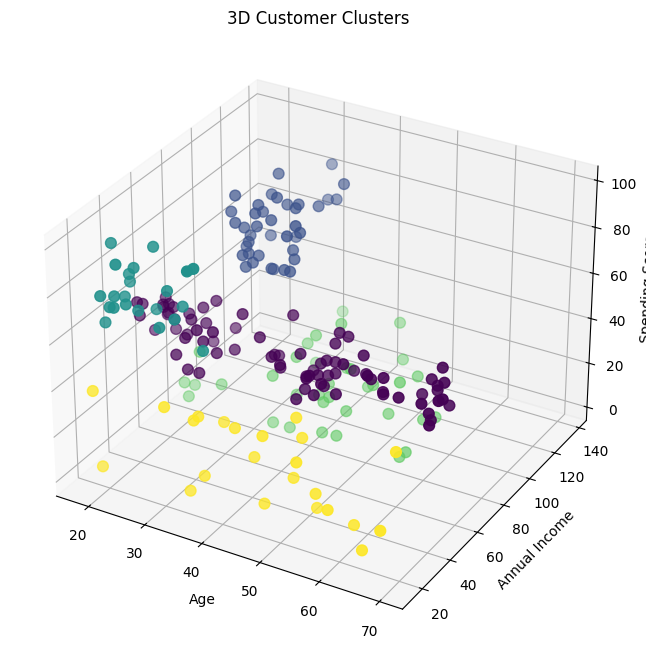

In [13]:
# 3D Visualization (Bonus)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Age'], df['Annual_Income'], df['Spending_Score'], c=df['Cluster_KMeans'], cmap='viridis', s=60)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')
plt.title('3D Customer Clusters')
plt.show()